# GC Dark Matter Annihilation — Monoenergetic Neutrino Line

Simulates the neutrino signal from $\chi\chi \to \nu\bar{\nu}$ (direct annihilation producing a monochromatic line at $E_0 = m_\chi$) using `GalacticHaloAnnihilationSource` with an NFW profile.

The flux is proportional to the **J-factor** ($\int \rho^2 \, dl$).

**DM parameters**
- $m_\chi = 1$ PeV
- $\langle\sigma v\rangle = 10^{-23}$ cm$^3$ s$^{-1}$ (optimistic, for statistics)
- $E_0 = m_\chi = 10^6$ GeV
- Profile: NFW with canonical Milky Way parameters

**Detector**: KM3NeT ARCA location (Mediterranean Sea, lat = +36.3°N)  
At this latitude the Galactic Centre (Dec ≈ −29°) is an upgoing source.

In [8]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from spore.conventions.units import units
from spore.detector.detector import Detector
from spore.event_sampling import GalacticHaloEventSampler
from spore.source import NFWProfile, GalacticHaloAnnihilationSource, LineSpectrum
from spore.source.jfactor import j_factor, psi_from_radec

RESOURCES = Path("../resources")

## Detector

In [9]:
detector_config = {
    "properties": {
        "latitude":  36.3,
        "longitude": 16.1,
        "medium":    "Water",
    },
    "response": {
        "detector_response_file": str(RESOURCES / "uniform_aeff_detector_response.h5")
    },
}
detector = Detector.from_config(detector_config)

## Source

For $\chi\chi \to \nu\bar{\nu}$ (Majorana DM), each annihilation produces 2 neutrinos at $E_0 = m_\chi$.

In [10]:
M_CHI_GEV = 1e6          # 1 PeV
SIGMA_V   = 1e-23         # cm^3/s — optimistic for getting statistics
E_0_EV    = M_CHI_GEV * 1e9  # line energy = m_chi for direct annihilation

profile  = NFWProfile(rho_s=0.3, r_s=20.0, r_sun=8.5)
spectrum = LineSpectrum(E_0_eV=E_0_EV, n_nu=2.0)  # 2 neutrinos per annihilation
source   = GalacticHaloAnnihilationSource(
    profile=profile,
    spectrum=spectrum,
    m_chi_gev=M_CHI_GEV,
    sigma_v_cm3s=SIGMA_V,
)

print(f"DM mass:     {M_CHI_GEV:.0e} GeV  ({M_CHI_GEV/1e6:.0f} PeV)")
print(f"sigma v:     {SIGMA_V:.0e} cm^3/s")
print(f"Line energy: {E_0_EV/1e12:.0f} TeV")

DM mass:     1e+06 GeV  (1 PeV)
sigma v:     1e-23 cm^3/s
Line energy: 1000 TeV


## Build sampler and check expected event rate

In [11]:
T_OBS_YEARS = 10.0
T_OBS       = T_OBS_YEARS * 365.25 * units.day
T_MJD       = 60355.0

print("Building flux × A_eff grid (takes ~1 min) ...")
sampler = GalacticHaloEventSampler(
    detector, source, burnin=10_000, n_dec=20, n_ra=21
)

n_track   = sampler.expected_events("track",   T_OBS)
n_cascade = sampler.expected_events("cascade", T_OBS)
print(f"Expected tracks:   {n_track:.1f}")
print(f"Expected cascades: {n_cascade:.1f}")

Building flux × A_eff grid (takes ~1 min) ...
Expected tracks:   10.2
Expected cascades: 10.2


## Sample events

In [16]:
print("Sampling track events ...")
events = sampler.sample_events("track", t=T_MJD, deltat=T_OBS)
print(f"Sampled {len(events)} track events.")

Sampling track events ...
Sampled 11 track events.


## Extract event quantities

In [17]:
true_decs  = np.degrees([e.true_direction.declination     for e in events])
true_ras   = np.degrees([e.true_direction.right_ascension for e in events])
reco_decs  = np.degrees([e.reco_direction.declination     for e in events])
reco_ras   = np.degrees([e.reco_direction.right_ascension for e in events])
reco_e_tev = np.array([(e.reco_energy / units.TeV).magnitude for e in events])

# Angle from Galactic Centre for each true direction
psis = np.degrees([
    psi_from_radec(np.radians(ra), np.radians(dec))
    for ra, dec in zip(true_ras, true_decs)
])

# True–reco angular separation
def angular_separation(e):
    v_t = e.true_direction.to_cartesian()
    v_r = e.reco_direction.to_cartesian()
    return np.degrees(np.arccos(np.clip(np.dot(v_t, v_r), -1.0, 1.0)))

ang_seps = np.array([angular_separation(e) for e in events])

print(f"Reco energy: median {np.median(reco_e_tev):.0f} TeV  "
      f"[{reco_e_tev.min():.0f}, {reco_e_tev.max():.0f}] TeV")
print(f"Angle from GC: median {np.median(psis):.1f} deg")
print(f"Angular res:   68th pct {np.percentile(ang_seps, 68):.2f} deg")

Reco energy: median 443 TeV  [188, 5251] TeV
Angle from GC: median 40.0 deg
Angular res:   68th pct 3.06 deg


## Plots

AttributeError: 'float' object has no attribute 'magnitude'

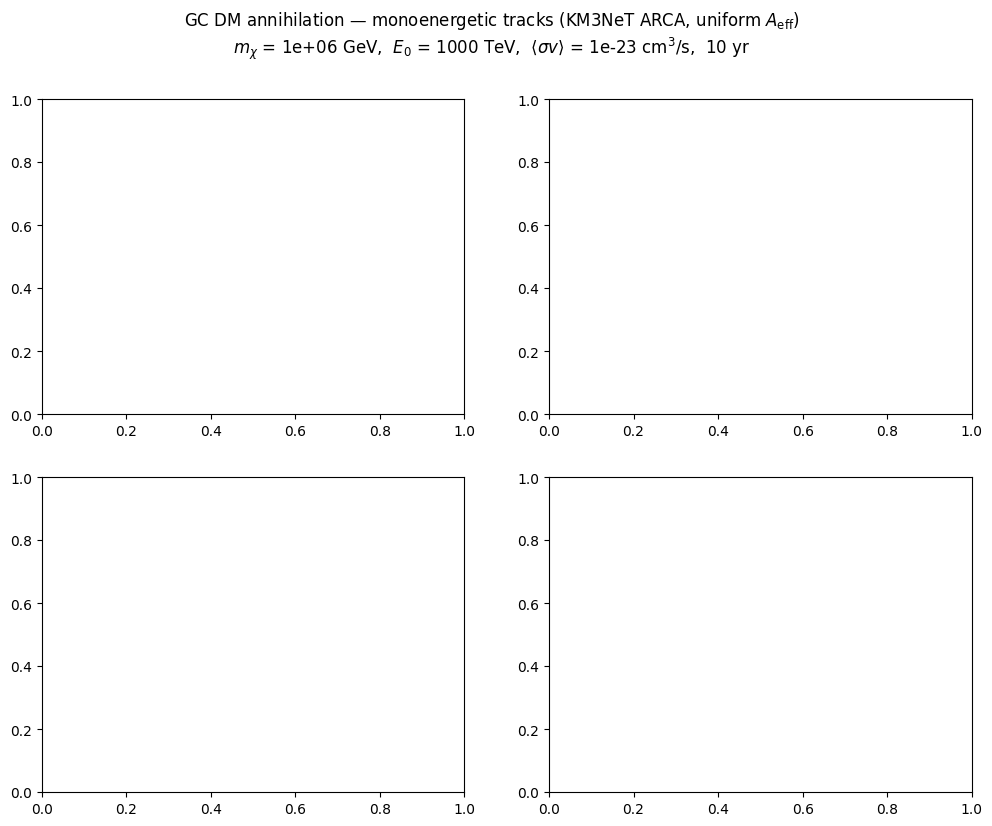

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle(
    f"GC DM annihilation — monoenergetic tracks (KM3NeT ARCA, uniform $A_{{\\rm eff}}$)\n"
    f"$m_\\chi$ = {M_CHI_GEV:.0e} GeV,  "
    f"$E_0$ = {E_0_EV/1e12:.0f} TeV,  "
    f"$\\langle\\sigma v\\rangle$ = {SIGMA_V:.0e} cm$^3$/s,  "
    f"{T_OBS_YEARS:.0f} yr",
    fontsize=12,
)

E_0_TEV = (E_0_EV / units.TeV).magnitude

# Sky map
ax = axes[0, 0]
ax.scatter(reco_ras, reco_decs, s=8, alpha=0.6, color="steelblue",
           rasterized=True, label="Reco directions")
ax.scatter([266.4], [-28.9], s=200, marker="*", color="tomato",
           zorder=5, label="Galactic Centre")
ax.set_xlabel("Right ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.set_title("Reconstructed sky positions")
ax.legend(fontsize=8)

# Angular distribution vs J-factor theory
ax = axes[0, 1]
psi_bins = np.linspace(0, 180, 41)
counts, edges = np.histogram(psis, bins=psi_bins)
bin_centres = 0.5 * (edges[:-1] + edges[1:])
pdf_events = counts / (counts.sum() * (psi_bins[1] - psi_bins[0]))
ax.step(bin_centres, pdf_events, where="mid", linewidth=1.5,
        color="steelblue", label="Sampled events")

psi_theory_deg = np.linspace(0.1, 179.9, 500)
psi_theory_rad = np.radians(psi_theory_deg)
j_vals = np.array([j_factor(profile, p) for p in psi_theory_rad])
pdf_theory = j_vals * np.sin(psi_theory_rad)
pdf_theory /= np.trapz(pdf_theory, psi_theory_deg)
ax.plot(psi_theory_deg, pdf_theory, color="tomato", linewidth=1.5,
        label=r"NFW $J(\psi)\cdot\sin(\psi)$")
ax.axvline(np.median(psis), color="gray", linestyle="--",
           label=f"Median = {np.median(psis):.1f}°")
ax.set_xlabel("Angle from Galactic Centre [deg]")
ax.set_ylabel("Probability density [deg⁻¹]")
ax.set_title("Angular distribution (true directions)")
ax.legend(fontsize=8)

# Reco energy spectrum
ax = axes[1, 0]
e_bins = np.logspace(
    np.log10(reco_e_tev.min() * 0.5),
    np.log10(reco_e_tev.max() * 2.0),
    30,
)
ax.hist(reco_e_tev, bins=e_bins, histtype="step", linewidth=1.5, color="steelblue")
ax.axvline(E_0_TEV, color="tomato", linestyle="--",
           label=f"$E_0$ = {E_0_TEV:.0f} TeV")
ax.set_xscale("log")
ax.set_xlabel("Reconstructed energy [TeV]")
ax.set_ylabel("Events / bin")
ax.set_title("Energy spectrum (line smeared by detector resolution)")
ax.legend()

# Angular resolution
ax = axes[1, 1]
ax.scatter(reco_e_tev, ang_seps, s=6, alpha=0.5, color="steelblue", rasterized=True)
ax.axhline(np.percentile(ang_seps, 68), color="tomato", linestyle="--",
           label=f"68th pct = {np.percentile(ang_seps, 68):.2f}°")
ax.set_xscale("log")
ax.set_xlabel("Reconstructed energy [TeV]")
ax.set_ylabel("True–reco angular separation [deg]")
ax.set_title("Angular resolution")
ax.legend()

plt.tight_layout()
plt.show()

## Validation: annihilation vs decay angular distributions

As a qualitative check: annihilation flux $\propto \rho^2$ is more GC-peaked than decay flux $\propto \rho$, so annihilation events should have a **smaller** median angle from the GC.

In [ ]:
from spore.source import GalacticHaloDecaySource
from spore.source.jfactor import d_factor

decay_spectrum = LineSpectrum(E_0_eV=E_0_EV / 2, n_nu=1.0)  # E_0 = m_chi/2 for decay
decay_source   = GalacticHaloDecaySource(
    profile=profile,
    spectrum=decay_spectrum,
    m_chi_gev=M_CHI_GEV,
    tau_s=1e28,
)

print("Building decay sampler ...")
decay_sampler = GalacticHaloEventSampler(
    detector, decay_source, burnin=10_000, n_dec=20, n_ra=21
)
decay_events = decay_sampler.sample_events("track", nevent=len(events))

decay_psis = np.degrees([
    psi_from_radec(
        e.true_direction.right_ascension,
        e.true_direction.declination,
    )
    for e in decay_events
])

print(f"Annihilation — median angle from GC: {np.median(psis):.1f} deg")
print(f"Decay        — median angle from GC: {np.median(decay_psis):.1f} deg")
print(f"Decay is broader: {np.median(decay_psis) > np.median(psis)}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

psi_bins = np.linspace(0, 90, 31)

ax.hist(psis,       bins=psi_bins, histtype="step", linewidth=1.5,
        density=True, color="steelblue", label=r"Annihilation ($J \propto \rho^2$)")
ax.hist(decay_psis, bins=psi_bins, histtype="step", linewidth=1.5,
        density=True, color="tomato",   label=r"Decay ($D \propto \rho$)")

# Overlay J and D theoretical curves
psi_t = np.linspace(0.1, 89.9, 300)
psi_r = np.radians(psi_t)

j_theory = np.array([j_factor(profile, p) for p in psi_r]) * np.sin(psi_r)
d_theory = np.array([d_factor(profile, p) for p in psi_r]) * np.sin(psi_r)
j_theory /= np.trapz(j_theory, psi_t)
d_theory /= np.trapz(d_theory, psi_t)

ax.plot(psi_t, j_theory, color="steelblue", linestyle="--", linewidth=1, alpha=0.7)
ax.plot(psi_t, d_theory, color="tomato",    linestyle="--", linewidth=1, alpha=0.7,
        label="Theory curves (dashed)")

ax.set_xlabel("Angle from Galactic Centre [deg]")
ax.set_ylabel("Probability density [deg⁻¹]")
ax.set_title("Annihilation vs decay: angular distribution from GC")
ax.legend()
plt.tight_layout()
plt.show()